# Exploración inicial - Puntaje Matemáticas
**Pregunta de negocio:** ¿Cuál será el nivel de desempeño en matemáticas de un estudiante de Cundinamarca según su tipo de colegio?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('Datos_Cundinamarca.csv')

## 1. Columnas relevantes

In [3]:
columnas = [
    'COLE_AREA_UBICACION',
    'COLE_BILINGUE',
    'COLE_GENERO',
    'COLE_JORNADA',
    'PUNT_MATEMATICAS'
]

df = df[columnas].copy()
print(f'Shape: {df.shape}')
df.head()

Shape: (470818, 5)


,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_JORNADA,PUNT_MATEMATICAS
0,URBANO,N,MIXTO,UNICA,26.0
1,URBANO,N,MIXTO,SABATINA,60.0
2,URBANO,NaN,MIXTO,COMPLETA,61.0
3,URBANO,N,MIXTO,COMPLETA,54.0
4,RURAL,N,MIXTO,SABATINA,45.0


## 2. Calidad de datos por columna

In [4]:
# Valores que se consideran "sin dato"
valores_nulos = {'na', 'nan', 'n/a', 'null', 'none', '-', ' ', ''}

print('=== Valores nulos y vacíos por columna ===')
for col in columnas:
    problemas = df[col].apply(
        lambda x: pd.isna(x) or str(x).strip().lower() in valores_nulos
    ).sum()
    pct = problemas / len(df) * 100
    print(f'{col}: {problemas} problemas ({pct:.1f}%) — {len(df) - problemas} datos útiles')

=== Valores nulos y vacíos por columna ===
COLE_AREA_UBICACION: 198 problemas (0.0%) — 470620 datos útiles
COLE_BILINGUE: 77355 problemas (16.4%) — 393463 datos útiles
COLE_GENERO: 0 problemas (0.0%) — 470818 datos útiles
COLE_JORNADA: 0 problemas (0.0%) — 470818 datos útiles
PUNT_MATEMATICAS: 0 problemas (0.0%) — 470818 datos útiles


In [5]:
print('=== Valores únicos por columna categórica ===\n')
for col in ['COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO', 'COLE_JORNADA']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()


=== Valores únicos por columna categórica ===

--- COLE_AREA_UBICACION ---
COLE_AREA_UBICACION
URBANO    374538
RURAL      96082
NaN          198
Name: count, dtype: int64

--- COLE_BILINGUE ---
COLE_BILINGUE
N      387376
NaN     77355
S        6087
Name: count, dtype: int64

--- COLE_GENERO ---
COLE_GENERO
MIXTO        464822
FEMENINO       4309
MASCULINO      1687
Name: count, dtype: int64

--- COLE_JORNADA ---
COLE_JORNADA
MAÑANA      201451
COMPLETA    133600
UNICA        41893
SABATINA     33164
TARDE        33095
NOCHE        27615
Name: count, dtype: int64



## 3. Letras a numeros

In [6]:
# COLE_BILINGUE: S -> 1, N -> 0
df['COLE_BILINGUE_NUM'] = df['COLE_BILINGUE'].map({'S': 1, 'N': 0})

# COLE_GENERO: Mixto -> 1, Femenino -> 2, Masculino -> 3
df['COLE_GENERO_NUM'] = df['COLE_GENERO'].map({'MIXTO': 1, 'FEMENINO': 2, 'MASCULINO': 3})

# COLE_JORNADA: todas las jornadas mapeadas
df['COLE_JORNADA_NUM'] = df['COLE_JORNADA'].map({
    'MAÑANA': 1,
    'COMPLETA': 2,
    'UNICA': 3,
    'TARDE': 4,
    'NOCHE': 5,
    'SABATINA': 6
})

# COLE_AREA_UBICACION: Urbano -> 0, Rural -> 1
df['COLE_AREA_UBICACION_NUM'] = df['COLE_AREA_UBICACION'].map({'URBANO': 0, 'RURAL': 1})

# DataFrame limpio solo con columnas numéricas + variable objetivo
df_limpio = df[[
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    'COLE_GENERO_NUM',
    'COLE_JORNADA_NUM',
]].dropna().reset_index(drop=True)

print(f'Shape final: {df_limpio.shape}')
print(f'Nulos restantes: {df_limpio.isna().sum().sum()}')
df_limpio.head()

Shape final: (393265, 4)
Nulos restantes: 0


,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_NUM,COLE_JORNADA_NUM
0,0.0,0.0,1,3
1,0.0,0.0,1,6
2,0.0,0.0,1,2
3,1.0,0.0,1,6
4,0.0,0.0,1,3


# Exploración de datos

## 3. Distribución de PUNT_MATEMATICAS y definición de categorías

In [7]:
print('=== Estadísticas de PUNT_MATEMATICAS ===')
print(df['PUNT_MATEMATICAS'].describe())
print(f'\nPercentil 33: {df["PUNT_MATEMATICAS"].quantile(0.33):.1f}')
print(f'Percentil 66: {df["PUNT_MATEMATICAS"].quantile(0.66):.1f}')

=== Estadísticas de PUNT_MATEMATICAS ===
count    470818.000000
mean         50.777481
std          11.344459
min           0.000000
25%          43.000000
50%          50.670000
75%          58.000000
max         127.000000
Name: PUNT_MATEMATICAS, dtype: float64

Percentil 33: 45.4
Percentil 66: 55.0


In [8]:
# Definir umbrales basados en percentiles 33 y 66
p33 = df['PUNT_MATEMATICAS'].quantile(0.33)
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

print(f'Umbrales:')
print(f'  Bajo  : PUNT_MATEMATICAS < {p33:.1f}')
print(f'  Medio : {p33:.1f} <= PUNT_MATEMATICAS < {p66:.1f}')
print(f'  Alto  : PUNT_MATEMATICAS >= {p66:.1f}')

def categorizar(puntaje):
    if pd.isna(puntaje):
        return np.nan
    elif puntaje < p33:
        return 'Bajo'
    elif puntaje < p66:
        return 'Medio'
    else:
        return 'Alto'

df['NIVEL_MATEMATICAS'] = df['PUNT_MATEMATICAS'].apply(categorizar)
print('\n=== Distribución de categorías ===')
print(df['NIVEL_MATEMATICAS'].value_counts())

Umbrales:
  Bajo  : PUNT_MATEMATICAS < 45.4
  Medio : 45.4 <= PUNT_MATEMATICAS < 55.0
  Alto  : PUNT_MATEMATICAS >= 55.0

=== Distribución de categorías ===
NIVEL_MATEMATICAS
Alto     172405
Bajo     151861
Medio    146552
Name: count, dtype: int64


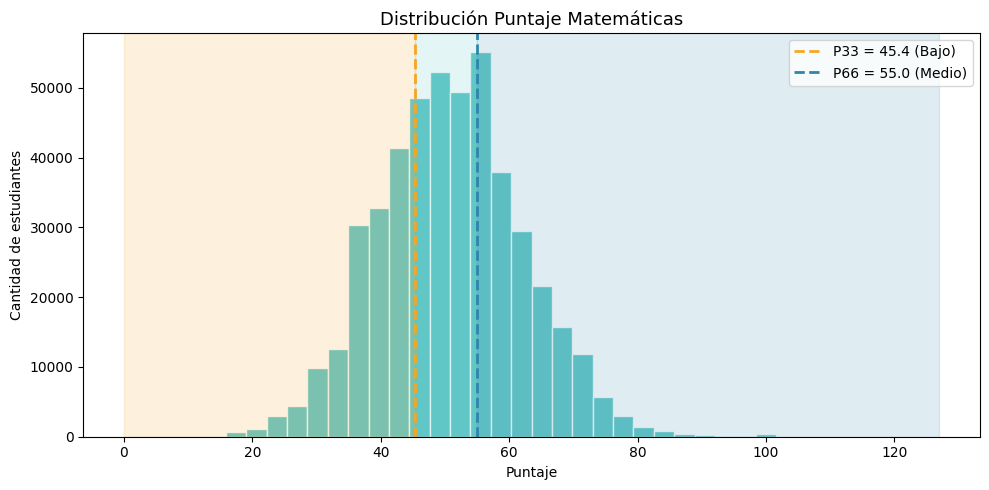

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(df['PUNT_MATEMATICAS'].dropna(), bins=40, color='#4ABFBF', edgecolor='white', alpha=0.85)

plt.axvline(p33, color='#F5A623', linestyle='--', linewidth=2, label=f'P33 = {p33:.1f} (Bajo)')
plt.axvline(p66, color='#2E86AB', linestyle='--', linewidth=2, label=f'P66 = {p66:.1f} (Medio)')

plt.axvspan(df['PUNT_MATEMATICAS'].min(), p33, alpha=0.15, color='#F5A623')
plt.axvspan(p33, p66, alpha=0.15, color='#4ABFBF')
plt.axvspan(p66, df['PUNT_MATEMATICAS'].max(), alpha=0.15, color='#2E86AB')

plt.title('Distribución Puntaje Matemáticas', fontsize=13)
plt.xlabel('Puntaje')
plt.ylabel('Cantidad de estudiantes')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_matematicas.png', dpi=150, bbox_inches='tight')
plt.show()

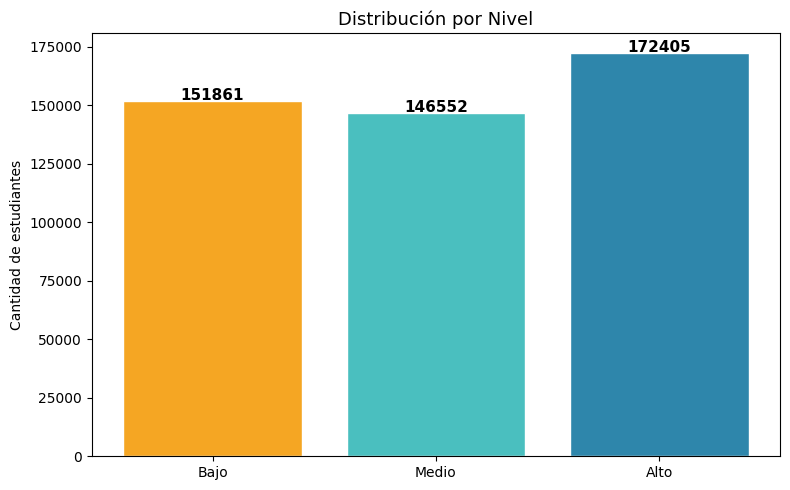

In [12]:
conteo = df['NIVEL_MATEMATICAS'].value_counts()[['Bajo', 'Medio', 'Alto']]

plt.figure(figsize=(8, 5))
bars = plt.bar(conteo.index, conteo.values, 
               color=['#F5A623', '#4ABFBF', '#2E86AB'], 
               edgecolor='white')

for bar, valor in zip(bars, conteo.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             str(valor), ha='center', fontweight='bold', fontsize=11)

plt.title('Distribución por Nivel', fontsize=13)
plt.ylabel('Cantidad de estudiantes')
plt.tight_layout()
plt.savefig('distribucion_por_nivel.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Paleta y orden canónico ──────────────────────
C = {'Bajo': '#F5A623', 'Medio': '#4ABFBF', 'Alto': '#2E86AB'}
ORDEN = ['Bajo', 'Medio', 'Alto']
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Reutilizar df_limpio ya construido ──
# df_limpio ya tiene: COLE_AREA_UBICACION_NUM, COLE_BILINGUE_NUM,
#                     COLE_GENERO_NUM, COLE_JORNADA_NUM
# df tiene: columnas originales categóricas + PUNT_MATEMATICAS + NIVEL_MATEMATICAS

p33 = df['PUNT_MATEMATICAS'].quantile(0.33)
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

print(f'Registros: {len(df_limpio):,}   |  p33={p33:.1f}  p66={p66:.1f}')
print(df['NIVEL_MATEMATICAS'].value_counts().reindex(ORDEN))

Registros: 393,265   |  p33=45.4  p66=55.0
NIVEL_MATEMATICAS
Bajo     151861
Medio    146552
Alto     172405
Name: count, dtype: int64


In [17]:
# ── Variable objetivo: puntaje continuo ────────
print('PUNT_MATEMATICAS — estadísticas generales')
print(df_eda['PUNT_MATEMATICAS'].describe().round(2).to_string())
print(f'  Asimetría : {df_eda["PUNT_MATEMATICAS"].skew():.4f}')
print(f'  Curtosis  : {df_eda["PUNT_MATEMATICAS"].kurt():.4f}')

print()
print('PUNT_MATEMATICAS — por nivel de desempeño')
tbl = df_eda.groupby('NIVEL')['PUNT_MATEMATICAS'].agg(
    N='count', Media='mean', Mediana='median',
    Std='std', Min='min', Max='max'
).reindex(ORDEN).round(2)
print(tbl.to_string())


PUNT_MATEMATICAS — estadísticas generales
count    393265.00
mean         50.55
std          11.24
min           0.00
25%          43.00
50%          50.00
75%          58.00
max         127.00
  Asimetría : 0.1721
  Curtosis  : 0.4460

PUNT_MATEMATICAS — por nivel de desempeño
            N  Media  Mediana   Std    Min     Max
NIVEL                                             
Bajo   128550  38.39    39.25  5.68   0.00   45.00
Medio  124114  49.84    50.00  2.59  45.38   54.94
Alto   140601  62.30    61.00  6.65  55.00  127.00
